# Assignment 7
## 1. Examination Registration Form

In [1]:
import tkinter as tk
from tkinter import messagebox

def register():
    if not name_entry.get() or not roll_entry.get() or not course_entry.get() or not subject_entry.get() or not semester_entry.get() or not email_entry.get():
        messagebox.showerror("Error", "All fields are required!")
    else:
        messagebox.showinfo("Success", "Registration Successful!")

def clear():
    name_entry.delete(0, tk.END)
    roll_entry.delete(0, tk.END)
    course_entry.delete(0, tk.END)
    subject_entry.delete(0, tk.END)
    semester_entry.delete(0, tk.END)
    email_entry.delete(0, tk.END)

root = tk.Tk()
root.title("Examination Registration Form")

tk.Label(root, text="Full Name:").grid(row=0, column=0, padx=10, pady=5)
name_entry = tk.Entry(root)
name_entry.grid(row=0, column=1, padx=10, pady=5)

tk.Label(root, text="Roll Number:").grid(row=1, column=0, padx=10, pady=5)
roll_entry = tk.Entry(root)
roll_entry.grid(row=1, column=1, padx=10, pady=5)

tk.Label(root, text="Course Name:").grid(row=2, column=0, padx=10, pady=5)
course_entry = tk.Entry(root)
course_entry.grid(row=2, column=1, padx=10, pady=5)

tk.Label(root, text="Subject:").grid(row=3, column=0, padx=10, pady=5)
subject_entry = tk.Entry(root)
subject_entry.grid(row=3, column=1, padx=10, pady=5)

tk.Label(root, text="Semester:").grid(row=4, column=0, padx=10, pady=5)
semester_entry = tk.Entry(root)
semester_entry.grid(row=4, column=1, padx=10, pady=5)

tk.Label(root, text="Email Address:").grid(row=5, column=0, padx=10, pady=5)
email_entry = tk.Entry(root)
email_entry.grid(row=5, column=1, padx=10, pady=5)

tk.Button(root, text="Register", command=register).grid(row=6, column=0, pady=10)
tk.Button(root, text="Clear", command=clear).grid(row=6, column=1, pady=10)

root.mainloop()

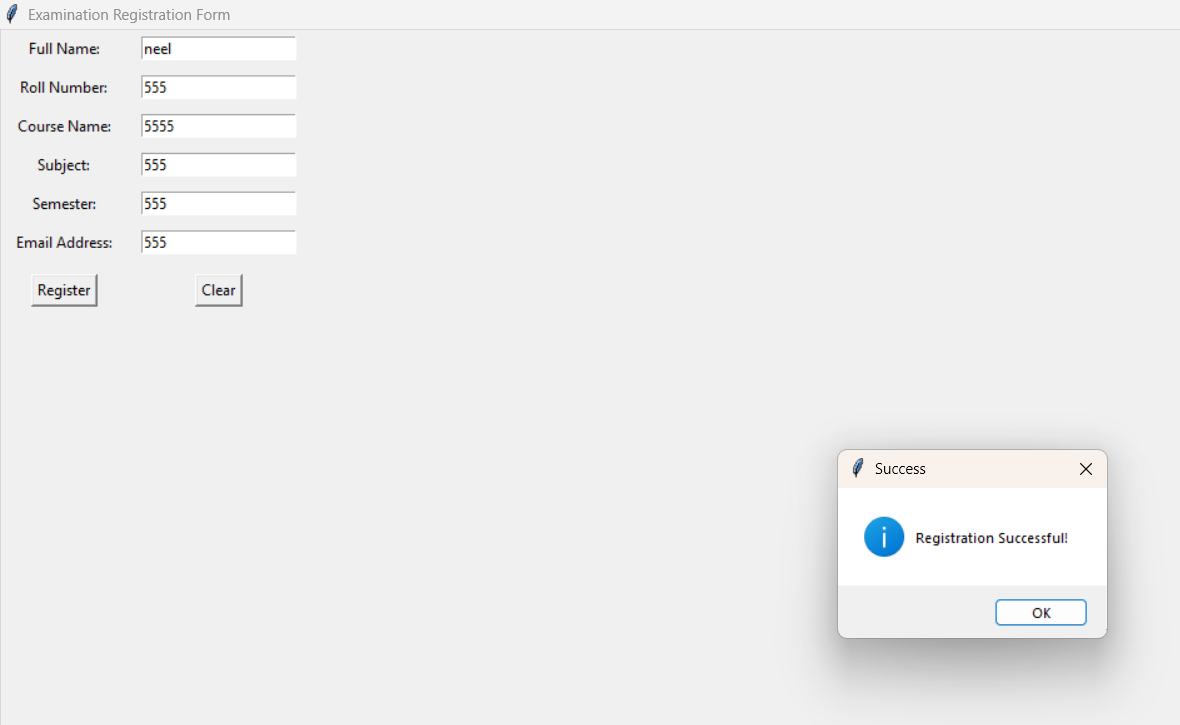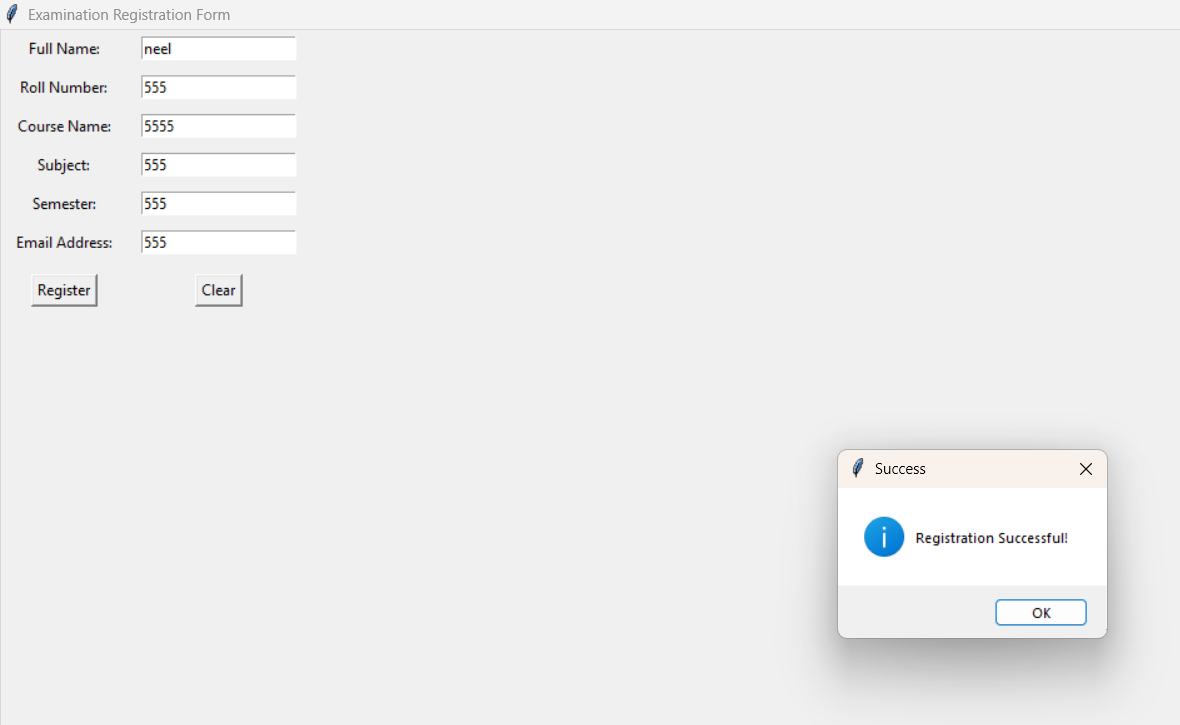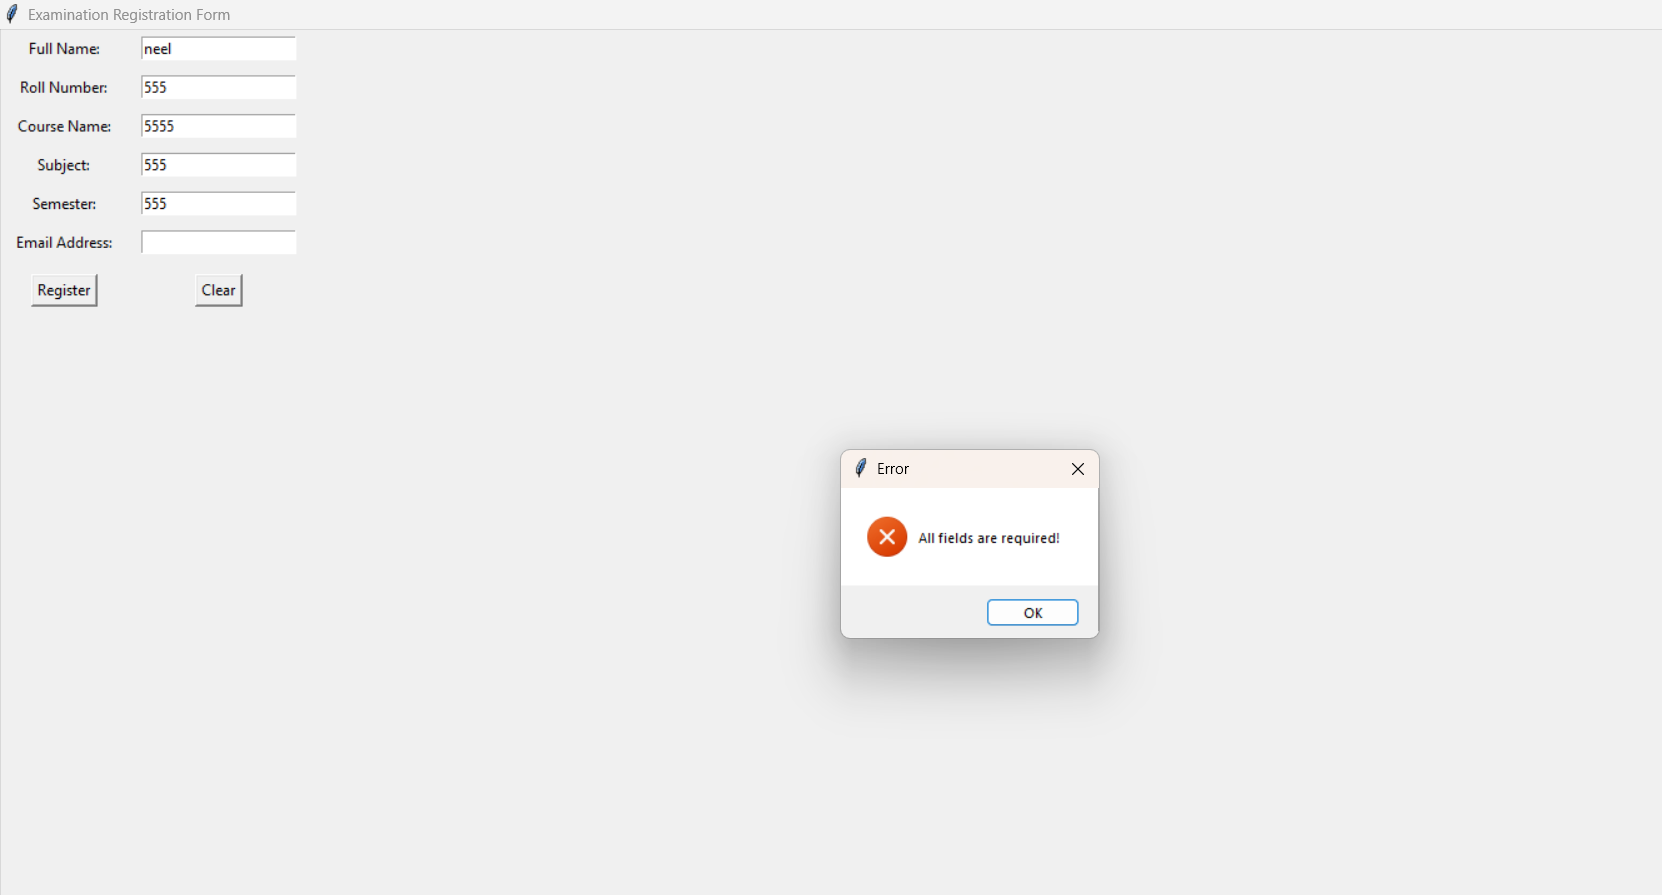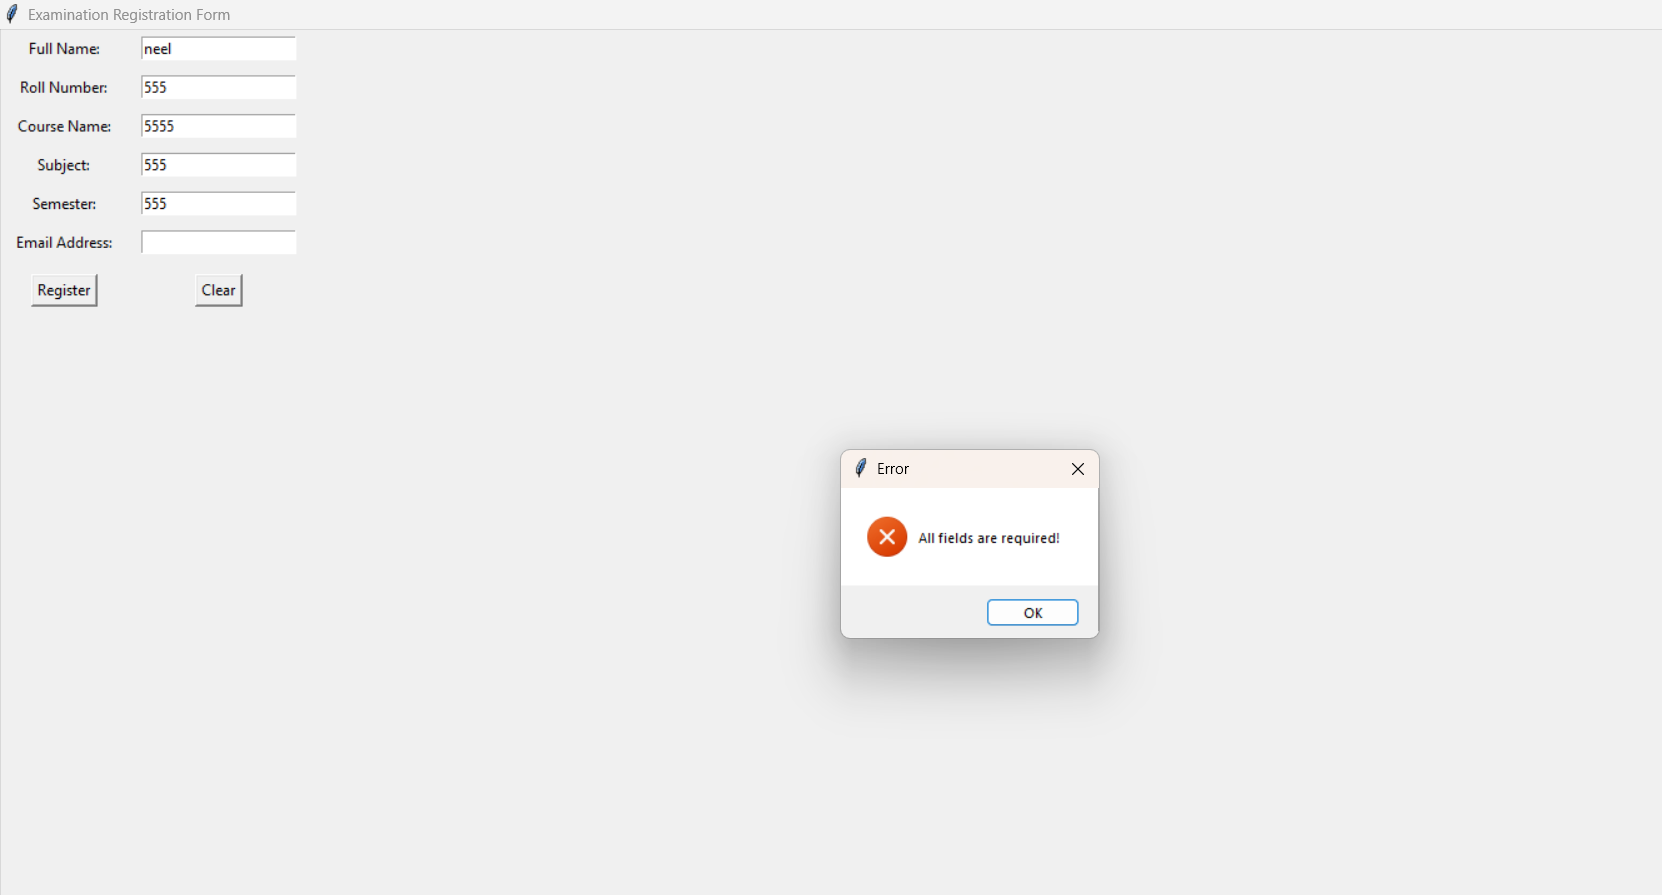

## 2. Student Record Management System

In [2]:
import tkinter as tk
from tkinter import messagebox

class Student:
    def __init__(self, name, marks):
        self.name = name
        self.marks = marks
        
    def display_result(self):
        if self.marks > 40:
            return "Pass"
        else:
            return "Fail"

def save_record():
    name = name_entry.get()
    marks_str = marks_entry.get()
    
    try:
        marks = float(marks_str)
        student = Student(name, marks)
        with open("students.txt", "a") as f:
            f.write(f"Name: {student.name}, Marks: {student.marks}, Result: {student.display_result()}\n")
        messagebox.showinfo("Success", "Record saved successfully!")
    except ValueError:
        messagebox.showerror("Error", "Invalid marks input (must be numeric)")
    except Exception as e:
        messagebox.showerror("Error", f"File error: {e}")

def show_result():
    name = name_entry.get()
    marks_str = marks_entry.get()
    try:
        marks = float(marks_str)
        student = Student(name, marks)
        result = student.display_result()
        messagebox.showinfo("Result", f"{name} is {result}")
    except ValueError:
        messagebox.showerror("Error", "Invalid marks input (must be numeric)")

root = tk.Tk()
root.title("Student Record Management System")

tk.Label(root, text="Name").grid(row=0, column=0, padx=10, pady=5)
name_entry = tk.Entry(root)
name_entry.grid(row=0, column=1, padx=10, pady=5)

tk.Label(root, text="Marks").grid(row=1, column=0, padx=10, pady=5)
marks_entry = tk.Entry(root)
marks_entry.grid(row=1, column=1, padx=10, pady=5)

tk.Button(root, text="Save Record", command=save_record).grid(row=2, column=0, pady=10)
tk.Button(root, text="Show Result", command=show_result).grid(row=2, column=1, pady=10)

root.mainloop()

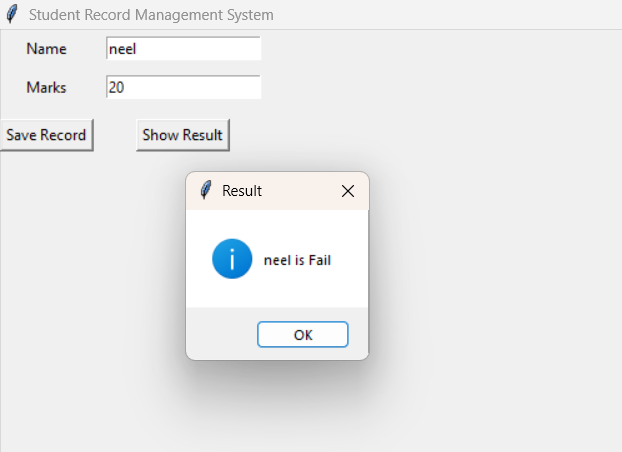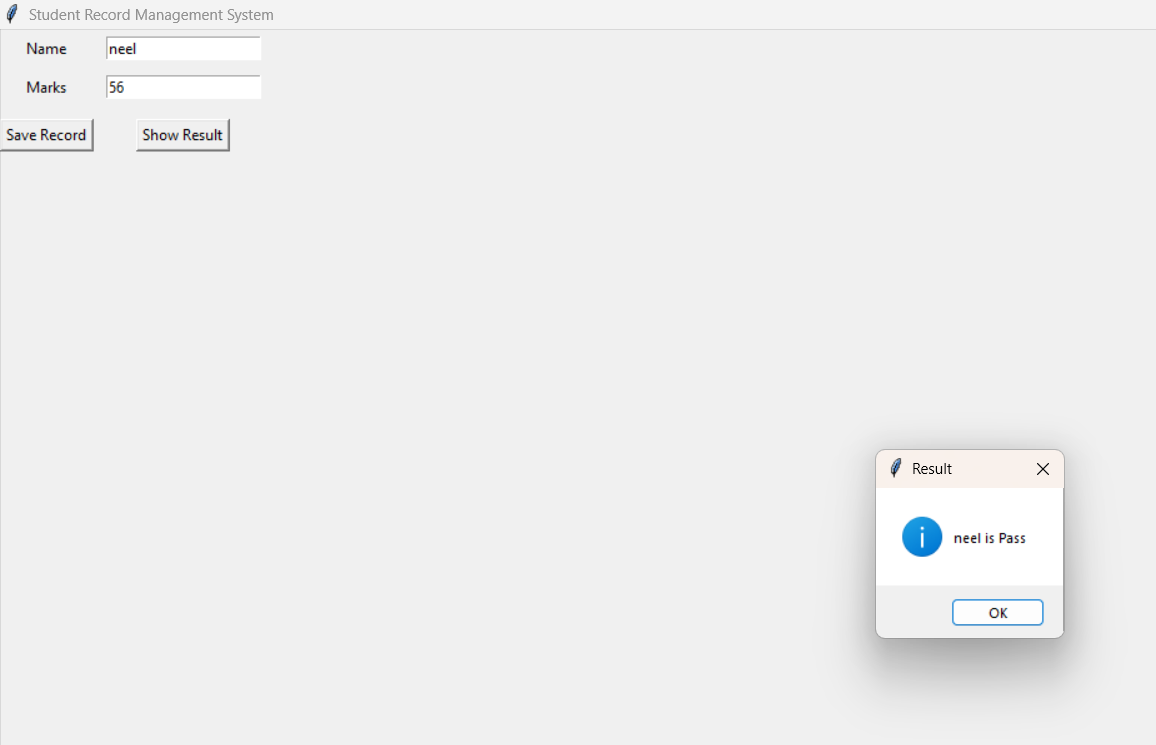

## 3. Student Information Form

In [3]:
import tkinter as tk
from tkinter import ttk, messagebox
import csv

def submit():
    if not agree_var.get():
        messagebox.showerror("Error", "You must agree to the terms and conditions")
        return
        
    data = {
        "Name": name_entry.get(),
        "Age": age_scale.get(),
        "Gender": gender_var.get(),
        "Course": course_var.get(),
        "Programming": prog_var.get(),
        "Maths": maths_var.get(),
        "Communication": comm_var.get(),
        "Hobbies": [hobbies_listbox.get(i) for i in hobbies_listbox.curselection()],
        "Comments": comments_text.get("1.0", tk.END).strip()
    }
    
    with open("student_info.csv", "a", newline='') as f:
        writer = csv.writer(f)
        writer.writerow([data["Name"], data["Age"], data["Gender"], data["Course"], 
                         data["Programming"], data["Maths"], data["Communication"], 
                         ", ".join(data["Hobbies"]), data["Comments"]])
    messagebox.showinfo("Success", "Data saved successfully!")

root = tk.Tk()
root.title("Student Information Form")
root.geometry("400x650")

tk.Label(root, text="Student Information Form", font=("Arial", 14, "bold")).pack(pady=10)

tk.Label(root, text="Name").pack()
name_entry = tk.Entry(root)
name_entry.pack()

tk.Label(root, text="Age").pack()
age_scale = tk.Scale(root, from_=18, to=100, orient=tk.HORIZONTAL)
age_scale.pack()

tk.Label(root, text="Gender").pack()
gender_var = tk.StringVar(value="Male")
tk.Radiobutton(root, text="Male", variable=gender_var, value="Male").pack()
tk.Radiobutton(root, text="Female", variable=gender_var, value="Female").pack()

tk.Label(root, text="Select Course").pack()
course_var = tk.StringVar(value="Select Course")
course_dropdown = ttk.Combobox(root, textvariable=course_var, values=["BTech", "MTech", "PhD"])
course_dropdown.pack()

tk.Label(root, text="Select Subjects").pack()
prog_var = tk.BooleanVar()
maths_var = tk.BooleanVar()
comm_var = tk.BooleanVar()
tk.Checkbutton(root, text="Programming", variable=prog_var).pack()
tk.Checkbutton(root, text="Maths", variable=maths_var).pack()
tk.Checkbutton(root, text="Communication", variable=comm_var).pack()

tk.Label(root, text="Select Hobbies").pack()
hobbies_listbox = tk.Listbox(root, selectmode=tk.MULTIPLE, height=4)
for item in ["Reading", "Gaming", "Sports", "Music"]:
    hobbies_listbox.insert(tk.END, item)
hobbies_listbox.pack()

tk.Label(root, text="comments").pack()
comments_text = tk.Text(root, height=4, width=30)
comments_text.pack()

agree_var = tk.BooleanVar()
tk.Checkbutton(root, text="I agree to the term and conditions", variable=agree_var).pack()

tk.Button(root, text="Submit", command=submit).pack(pady=10)

root.mainloop()

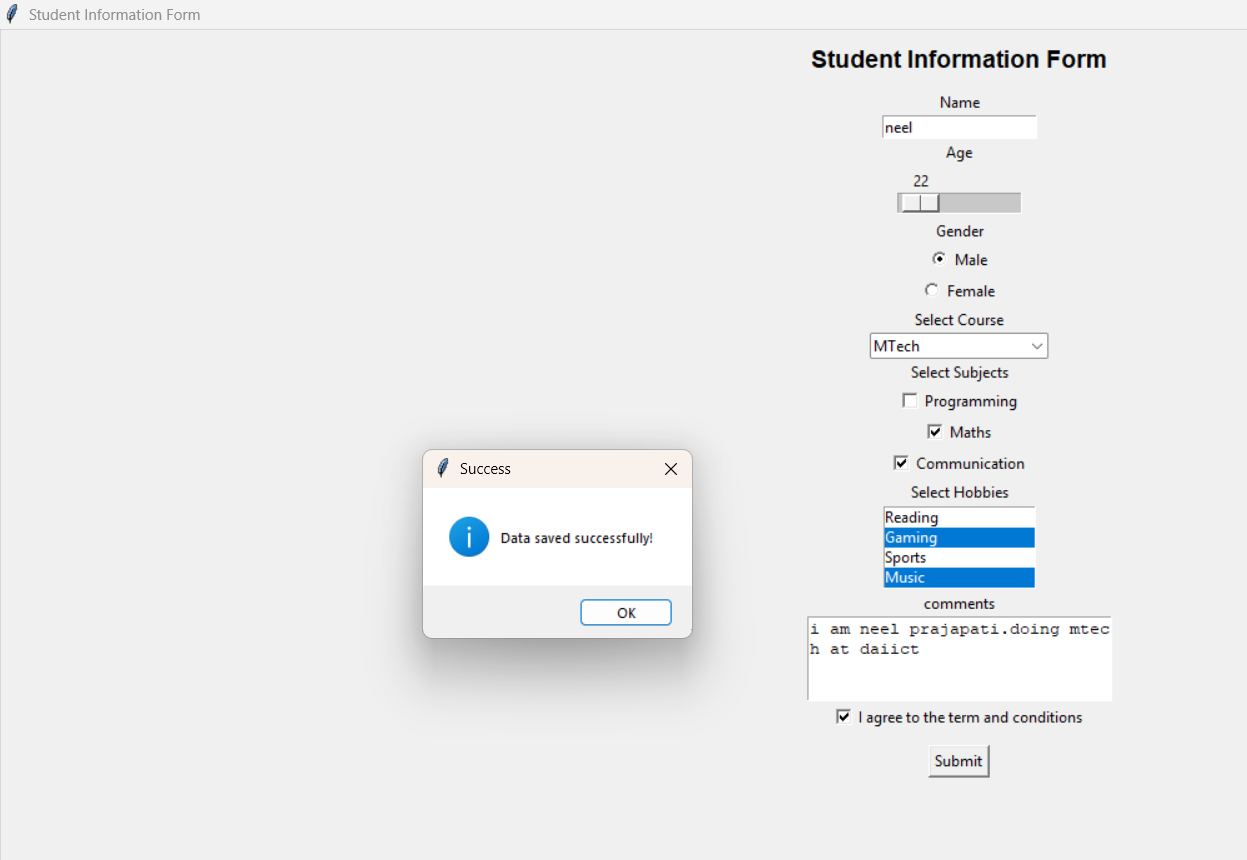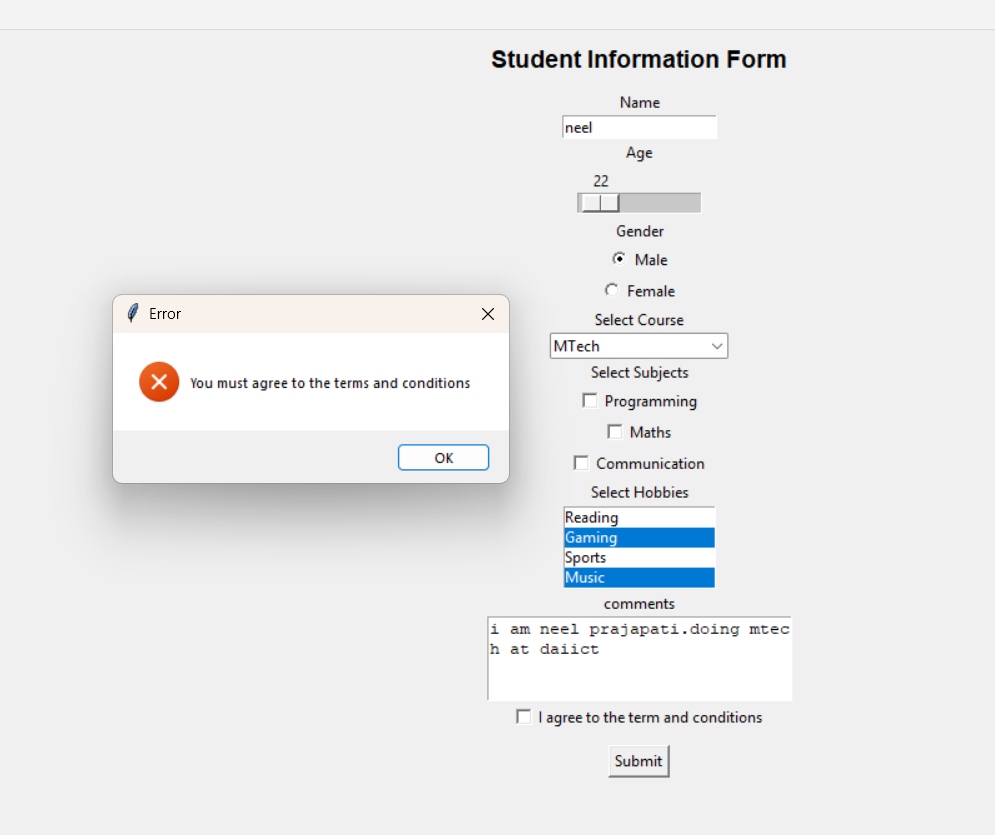

## 4. Simple Calculator

In [4]:
import tkinter as tk
from tkinter import messagebox

def calculate():
    try:
        num1 = float(entry1.get())
        num2 = float(entry2.get())
        result_label.config(text=f"Result is {num1 + num2}")
    except ValueError:
        messagebox.showerror("Error", "Please enter valid numbers")

root = tk.Tk()
root.title("Simple Calculator")

tk.Label(root, text="Simple Calculator", font=("Arial", 12)).grid(row=0, column=0, columnspan=2, pady=10)

tk.Label(root, text="Enter a number").grid(row=1, column=0, padx=5, pady=5)
entry1 = tk.Entry(root)
entry1.grid(row=1, column=1, padx=5, pady=5)

tk.Label(root, text="Enter another number").grid(row=2, column=0, padx=5, pady=5)
entry2 = tk.Entry(root)
entry2.grid(row=2, column=1, padx=5, pady=5)

tk.Button(root, text="Calculate", command=calculate).grid(row=3, column=0, pady=10)
result_label = tk.Label(root, text="")
result_label.grid(row=3, column=1, pady=10)

root.mainloop()

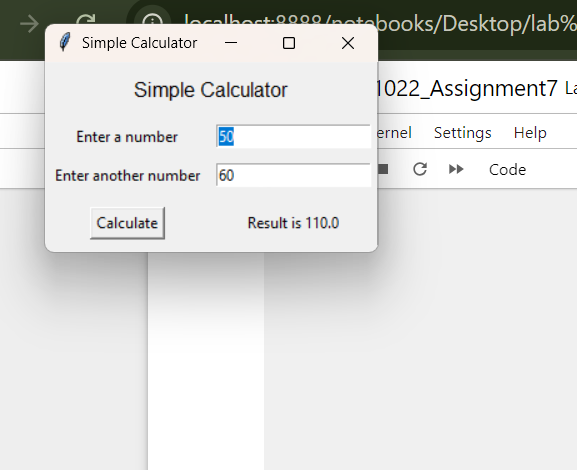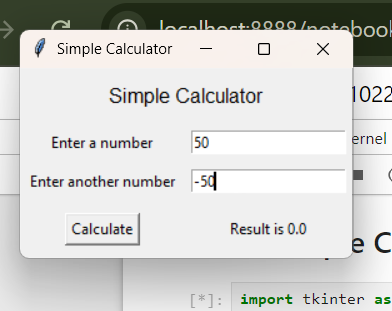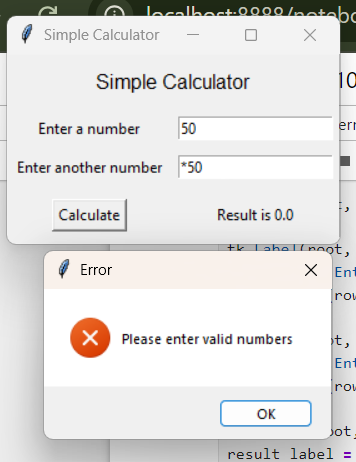

## 5. m to Km converter

In [ ]:
import tkinter as tk
from tkinter import messagebox

def convert():
    try:
        meters = float(entry.get())
        km = meters / 1000
        result_label.config(text=f"{km} Km")
    except ValueError:
        messagebox.showerror("Error", "Please enter a valid number")

root = tk.Tk()
root.title("Demo App")
root.geometry("400x200")

tk.Label(root, text="m to Km converter", font=("Arial", 12)).pack(pady=10)

frame = tk.Frame(root)
frame.pack(pady=10)

tk.Label(frame, text="Enter the value in meter").grid(row=0, column=0, padx=5)
entry = tk.Entry(frame)
entry.grid(row=0, column=1, padx=5)
tk.Button(frame, text="Convert", command=convert).grid(row=0, column=2, padx=5)

result_label = tk.Label(root, text="Km")
result_label.pack(pady=10)

root.mainloop()

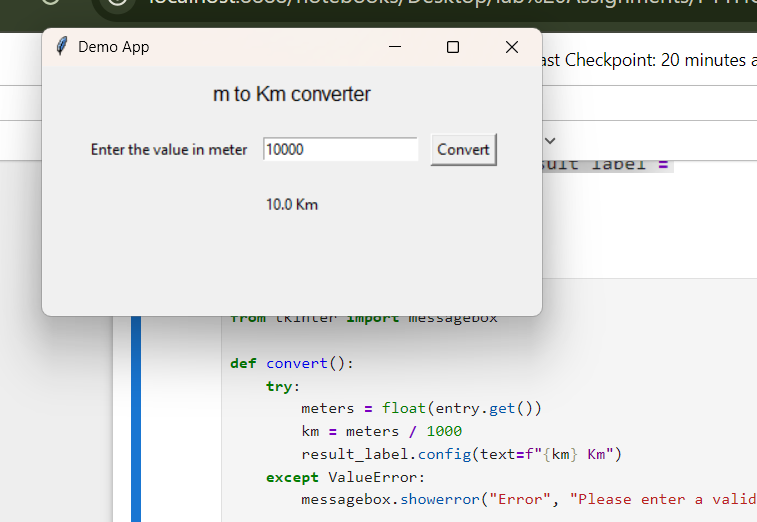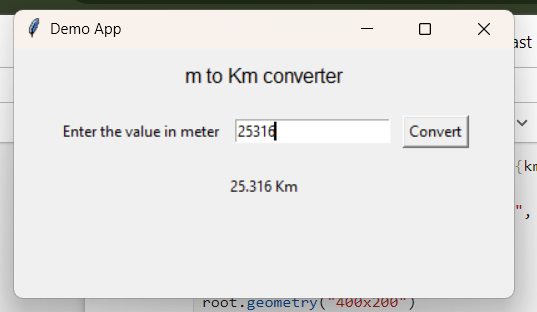